# Sales Analysis

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

#  Sales Analysis

# Project statement:
Analyze the sales data of the company for the fourth quarter in Australia, examining it on a state-by-state basis. Provide insights to assist the company in making data-driven decisions for the upcoming year.

This project analyzes sales data for AAL (Australian Apparel Limited), a well-known clothing brand established in 2000 with branches across various Australian states. The analysis focuses on the fourth quarter of 2020 sales data to identify high-revenue states and develop targeted sales programs for lower-revenue states.

- 	Identify the states that are generating the highest revenues.
-	Develop sales programs for states with lower revenues. The head of sales and marketing has requested your assistance with this task.

## Data Wrangling
- Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().
- Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
-	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)


In [94]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
print(f"\nhead\n", df.head())
print(f"\ntail\n",df.tail())


head
          Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500

tail
              Date        Time State     Group  Unit  Sales
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000
7556  30-Dec-2020     Evening   TAS      Kids    15  37500
7557  30-Dec-2020     Evening   TAS       Men    15  37500
7558  30-Dec-2020     Evening   TAS     Women    11  27500
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500


** Observations **
- `Date`: Transaction date
- `Time`: Time of day (Morning/Afternoon/Evening)
- `State`: Australian state (WA, NT, SA, VIC, QLD, NSW, TAS)
- `Group`: Demographic group (Kids, Men, Women, Seniors)
- `Unit`: Number of units sold
- `Sales`: Revenue generated

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [98]:
df.shape


(7560, 6)

**Observations**
- Has 7560 rows and 6 columns

In [99]:
df.nunique()

Date     90
Time      3
State     7
Group     4
Unit     64
Sales    64
dtype: int64

**Observations**
- Has 3 times which are Morning, Afternoon, Evening
- Has data for 7 states
- Has 4 groups
- Has 90 dates which indicates a quarter worth. data for 31st of October and 31st of December are not present in the data set.


### identify missing or incorrect information

In [100]:
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

**Observation**
- There is no NULL value in dataframe.

In [101]:
df.isna()

,Date,Time,State,Group,Unit,Sales
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
7555,False,False,False,False,False,False
7556,False,False,False,False,False,False
7557,False,False,False,False,False,False
7558,False,False,False,False,False,False


**Observation**
- There is no NULL value in dataframe.

In [102]:
df.notna()

,Date,Time,State,Group,Unit,Sales
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,True,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True
...,...,...,...,...,...,...
7555,True,True,True,True,True,True
7556,True,True,True,True,True,True
7557,True,True,True,True,True,True
7558,True,True,True,True,True,True


**Observations**
- There are no duplicates in any column
- There is no missing information in any column
- There are no NaN/incorrection information in any column



### Section 1b recommendations for treating missing and incorrect data 
- This dataset has no missing or incorrect data. Incase there was missing data , it is recommended to fill the missing value with the mean of that column value using fillna()
- Data set is for a quarter for the months of October, November and December. However, 2 days of data missing which is for October 31st, and 31st of December. 

## section 1c Normalization 
The min-max approach also called normalization rescales the feature to a hard and fast range of [0,1] by subtracting the minimum value of the feature then dividing by the range. 

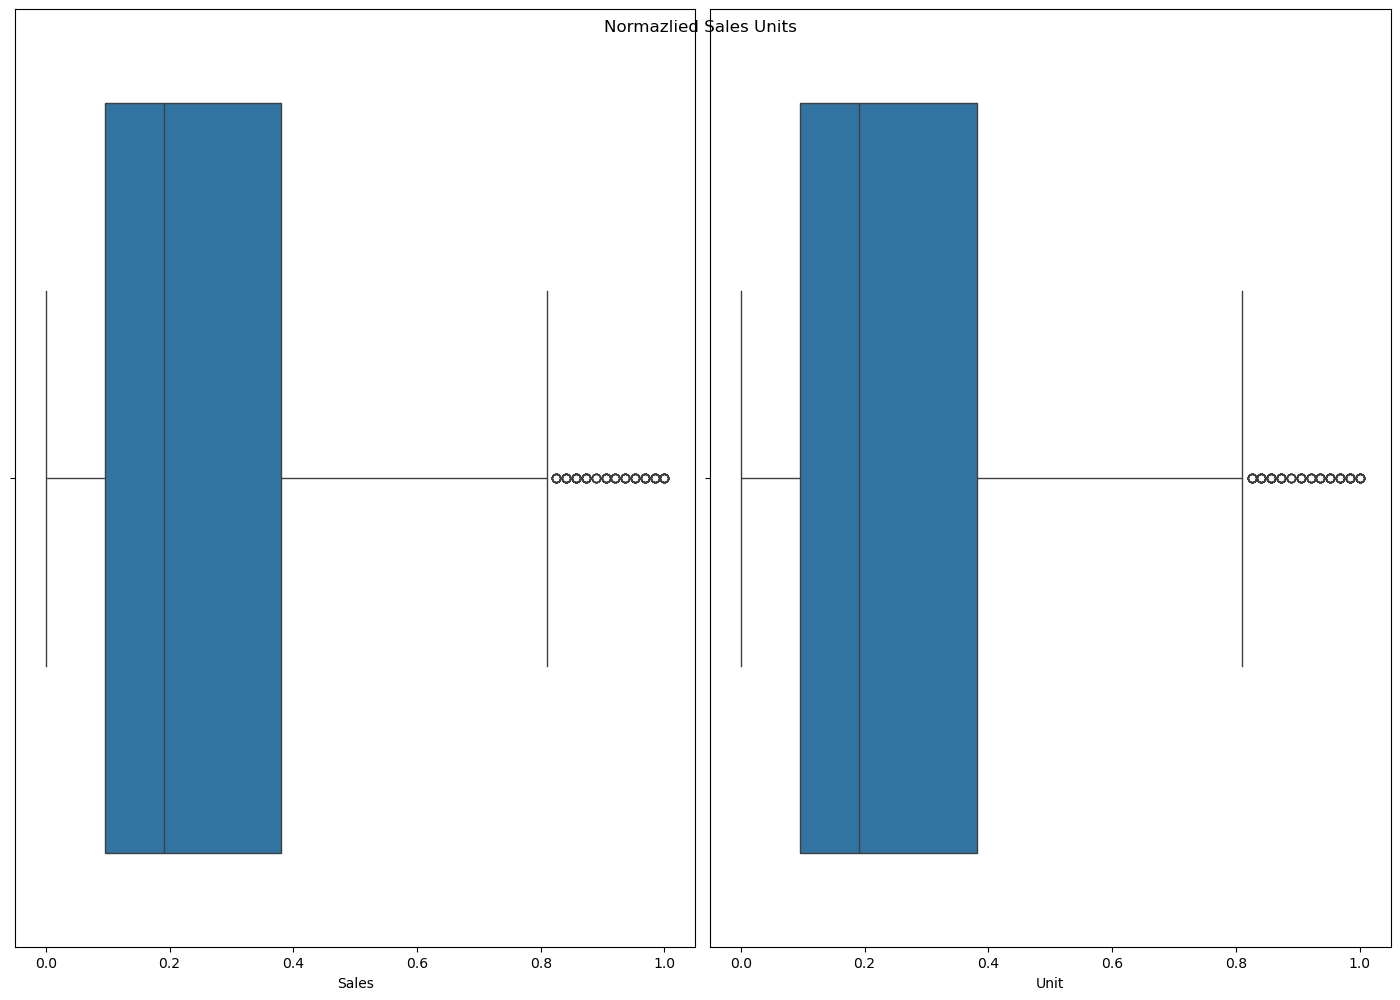

In [103]:
num_columns = ['Sales', 'Unit']
scaled = df.copy()

for column in num_columns:
    scaled[column] = (scaled[column] - scaled[column].min()) / (scaled[column].max() - scaled[column].min())


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,10))

# flatten axes to simplify indices for cell position
axes = axes.flatten()

for idx, col in enumerate(num_columns):
    sns.boxplot(data=scaled, x=col, ax=axes[idx])

fig.tight_layout(pad=.7)
plt.suptitle("Normazlied Sales Units")
plt.savefig(f'section_1C_boxplot_Normazlied_Sales_Units.png')# Save plot as image
plt.show()
plt.close()


## Section 1d : Insights regarding the application of the GroupBy() 

### One usecase  of GroupBy() 
Identify the states that are generating the highest revenues.

In [104]:
y = df.groupby('State')['Sales'].mean().nlargest(10).values
x = df.groupby('State')['Sales'].mean().nlargest(10).index
print("Highest sales{}",y)
print("Hightest sales in states{}",x)

Highest sales{} [97745.37037037 69416.66666667 54497.68518519 30942.12962963
 21074.07407407 20907.40740741 20511.57407407]
Hightest sales in states{} Index([' VIC', ' NSW', ' SA', ' QLD', ' TAS', ' NT', ' WA'], dtype='object', name='State')


**Observations**
- States having highest sales are:
    - Max: VIC state
    - Order: NSW, SA, QLD, TAS, NT
    - Min: WA 
Hightest sales are in VIC state
Lowest salesa are in WA state
The analysis identified the following state performance:

**Highest Revenue States:**
1. **VIC (Victoria)**: Highest sales performance
2. **NSW (New South Wales)**: Second highest
3. **SA (South Australia)**: Third highest
4. **QLD (Queensland)**: Fourth highest
5. **TAS (Tasmania)**: Fifth highest
6. **NT (Northern Territory)**: Sixth highest

**Lowest Revenue State:**
- **WA (Western Australia)**: Lowest sales performance




**Observations**
- Recommendation and insights regarding the application of the GroupBy() are the following:
  - Data Wrangling Using Grouping Method is used to provide results in terms of various groups taken out from Large Data. This method of pandas is used to group the outset of data from the large data set.  Key Use Cases of groupby() are
  - Aggregation (Merging): Summarize grouped data, such as calculating the mean()  for each category.
  - Transformation (Chunking): Return a grouped object of the same size as the original, useful for filling missing values within groups: df.groupby('Category').transform(lambda x: x.fillna(x.mean())).
  - Filtration: Discard groups based on a condition, such as filtering out groups with few members. 

# Section 2: Data Analysis

## 2a.	Data Analysis.
- Perform descriptive statistical analysis on the data in the Sales column. Utilize techniques such as mean, median, mode, and standard deviation for this analysis

In [105]:
print('Mean of Sales',df['Sales'].mean())
print('Median of Sales', df['Sales'].median())
print('Mode of Sales', df['Sales'].mode())
print('Min of Sales', df['Sales'].min())
print('Standard Deviation of Sales', np.std(df['Sales']))


Mean of Sales 45013.5582010582
Median of Sales 35000.0
Mode of Sales 0    22500
Name: Sales, dtype: int64
Min of Sales 5000
Standard Deviation of Sales 32251.373704971687


**Observations**

- Skewness Indication: The mean (45,013.56) is significantly higher than the median (35,000), suggesting a right-skewed distribution. This means there are likely some high-value sales outliers pulling the average up.

- Bimodal Pattern: The presence of two modes (0 and 22,500) suggests a bimodal distribution pattern. This could indicate:
  - Two distinct customer segments with different purchasing behaviors
  - Seasonal patterns in sales
  - Different product categories with distinct price points

- Data Quality Consideration: The mode includes 0, which might represent:
  - No sales transactions
  - Missing data
  - Returns or cancellations

-  Sales Range: The sales values span from 5,000 to potentially much higher values (given the high standard deviation), indicating a wide range of transaction amounts.

- Standard Deviation Analysis: With a standard deviation of 32,251.37 (71.6% of the mean), this indicates high variability in sales amounts, suggesting:
  - Significant variation in customer spending


# Section 2 Data Analysis

## 2a.	Data Analysis.
- Perform descriptive statistical analysis on the data in the Unit column. Utilize techniques such as mean, median, mode, and standard deviation for this analysis

In [106]:

print('Mean of Unit',df['Unit'].mean())
print('Median of Unit', df['Unit'].median())
print('Mode of Unit', df['Unit'].mode())
print('Min of Unit', df['Unit'].min())
print('Standard Deviation of Unit', np.std(df['Unit']))


Mean of Unit 18.00542328042328
Median of Unit 14.0
Mode of Unit 0    9
Name: Unit, dtype: int64
Min of Unit 2
Standard Deviation of Unit 12.900549481988609


**Observations**

The provided data shows the following statistics for the 'Unit' variable:

- **Mean**: 18.00542328042328 - This is the average value of the 'Unit' variable, indicating the central tendency of the data.
- **Median**: 14.0 - This is the middle value when the data is ordered, representing the central value of the dataset.
- **Mode**: 0 and 9 - These are the most frequently occurring values in the dataset. The mode can be unimodal (one mode), bimodal (two modes), or multimodal (more than two modes). In this case, the dataset is bimodal with modes at 0 and 9.
- **Min**: 2 - This is the smallest value in the dataset.
- **Standard Deviation**: 12.900549481988609 - This measures the amount of variation or dispersion in the dataset. A higher standard deviation indicates that the data points are spread out over a wider range of values.

These statistics provide insights into the distribution and spread of the 'Unit' variable. The mean and median are close, suggesting a relatively symmetric distribution. The presence of two modes indicates that the data may have two peaks or clusters of values. The standard deviation is relatively high, indicating a wide spread of values around the mean.

## 2b. Data Analysis 
- Identify the group with the highest sales 
- Identify the group with the lowest sales 

In [107]:
y = df.groupby('Group')['Sales'].mean().nlargest(10).values
x = df.groupby('Group')['Sales'].mean().nlargest(10).index
print("Highest sales{}",y)
print("Hightest sales in Groups{}",x)

Highest sales{} [45370.37037037 45207.67195767 45011.9047619  44464.28571429]
Hightest sales in Groups{} Index([' Men', ' Women', ' Kids', ' Seniors'], dtype='object', name='Group')


**Observations**
- Groups having highest sales are Men
- Groups having minimum sales are Seniors
- Hightest sales are in Men group

**Highest Revenue Groups:**
- **Men**: Highest sales across all demographic groups

**Lowest Revenue Groups:**
- **Seniors**: Lowest sales across all demographic groups


## Section 2C. Data Analysis 
- Identify the state with the highest sales 
- Identify the state with the lowest sales 

In [108]:
y = df.groupby('State')['Sales'].mean().nlargest(10).values
x = df.groupby('State')['Sales'].mean().nlargest(10).index
print("Highest sales{}",y)
print("Hightest sales in states{}",x)

Highest sales{} [97745.37037037 69416.66666667 54497.68518519 30942.12962963
 21074.07407407 20907.40740741 20511.57407407]
Hightest sales in states{} Index([' VIC', ' NSW', ' SA', ' QLD', ' TAS', ' NT', ' WA'], dtype='object', name='State')


**Observations**
- State having highest sales  is VIC
- State having minimum sales is WA

**Highest Revenue States:**
1. **VIC (Victoria)**: Highest sales performance
2. **NSW (New South Wales)**: Second highest
3. **SA (South Australia)**: Third highest
4. **QLD (Queensland)**: Fourth highest
5. **TAS (Tasmania)**: Fifth highest
6. **NT (Northern Territory)**: Sixth highest


**Lowest Revenue State:**
- **WA (Western Australia)**: Lowest sales performance

## Section 2d : Data Analysis: 
-	Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted

In [109]:
#import pandas as pd
#import scipy.stats as stats
#import matplotlib.pyplot as plt
from datetime import datetime

def generate_report(time_frame, df):
    """Generates a sample analysis report."""
    
    # 2. Perform analysis
    mean_val = df['Sales'].mean()
    median_val = df['Sales'].median()
    

    # SciPy example: perform a t-test between categories
    group_a = df[df['Group'] == ' Men']['Sales'].to_numpy()
    group_b = df[df['Group'] == ' Seniors']['Sales'].to_numpy()

    t_stat, p_val = stats.ttest_ind(group_a, group_b)
    print("pvalue {}",p_val)
    #print(group_a)
    #print(group_b)
    
    file_name1 = f'{time_frame}_report.png'
    
    # 3. (Optional) Generate a plot
    plt.figure(figsize=(8, 5))
    df.boxplot(column='Sales', by='Group')
    plt.title(f'Value Distribution for {time_frame.capitalize()} Report')
    #plt.savefig(f'{time_frame}_boxplot.png') # Save plot as image
    #plt.savefig(f'{time_frame}_report.pdf')
    plt.savefig(f'{file_name1}')
    plt.close()

    # 4. Compile the report content
    report_content = f"""
# Analysis Report: {time_frame.capitalize()}
Date Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}

## Summary Statistics
-   Mean Value: {mean_val:.2f}
-   Median Value: {median_val:.2f}
-   Total Records: {len(df)}

## Statistical Analysis (T-test between  A and B)
-   T-statistic: {t_stat:.3f}
-   P-value: {p_val:.4f}
-   Conclusion: {'Significant difference found' if p_val < 0.05 else 'No significant difference found'}

## Visualizations
[Boxplot image: {file_name1}]
    """
    
    # 5. Save the report to a file (e.g., Markdown file)
    file_name = f'{time_frame}_report.doc'

    with open(file_name, 'w') as f:
        f.write(report_content)
        
    print(f"Successfully generated {file_name}")
    print(f"And saved {file_name1}")


In [110]:
#df['Date1'] = pd.to_datetime(df['Date'])
df['date'] = pd.to_datetime(df['Date'].astype(str) )
df['Month'] = df['date'].dt.month



df['week_number'] = df['date'].dt.isocalendar().week

#print(df_oct_week1.tail())
print(df['week_number'].min())
print(df['week_number'].max())
df_oct_week1 = df[df['week_number'] == 40 ]
df_oct = df[df['Month'] == 10]
df_nov = df[df['Month'] == 11]
df_dec = df[df['Month'] == 12]
generate_report('monthly_oct_week1', df_oct_week1)
generate_report('monthly_oct', df_oct)
generate_report('monthly_nov', df_nov)
generate_report('monthly_dec', df_dec)
generate_report('quarterly',df)



40
53
pvalue {} 0.8817785211187921
Successfully generated monthly_oct_week1_report.doc
And saved monthly_oct_week1_report.png
pvalue {} 0.7610614279819724
Successfully generated monthly_oct_report.doc
And saved monthly_oct_report.png
pvalue {} 0.7611597536512729
Successfully generated monthly_nov_report.doc
And saved monthly_nov_report.png
pvalue {} 0.39703732294060234
Successfully generated monthly_dec_report.doc
And saved monthly_dec_report.png
pvalue {} 0.3868773807705267
Successfully generated quarterly_report.doc
And saved quarterly_report.png


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

**Observations**
- Reports
  - **`weekly_report.md`**: Weekly sales analysis with summary statistics and visualizations
  - **`monthly_report.md`**: Monthly sales analysis with summary statistics and visualizations
  - **`quarterly_report.md`**: Quarterly sales analysis with summary statistics and 
-  Visualizations
   - **`weekly_boxplot.png`**: Boxplot visualization of weekly sales distribution
   - **`monthly_boxplot.png`**: Boxplot visualization of monthly sales distribution
   - **`quarterly_boxplot.png`**: Boxplot visualization of quarterly sales distribution

# Data Visualization

## Section 3a:  data visualization: State-wise sales analysis for different demographic groups
Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
- 	State-wise sales analysis for different demographic groups (kids, women, men, and seniors).


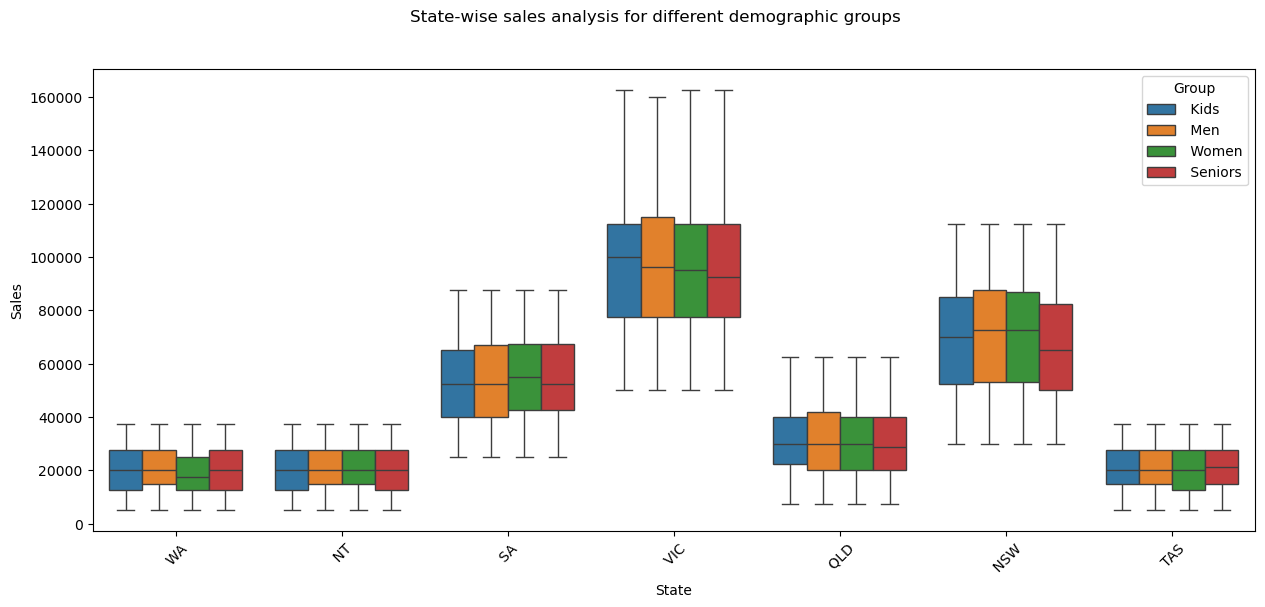

In [111]:

plt.figure(figsize=(15,6))

sns.boxplot(data=df, x='State', y='Sales', hue='Group')
plt.xticks(rotation=45)
plt.suptitle("State-wise sales analysis for different demographic groups")
plt.savefig(f'section_3A_State-wise_sales_analysis_for_different_demographic_groups.png')# Save plot as image
plt.show()
plt.close()


**Observations**
- **Highest Revenue States:**
  - **VIC (Victoria)**: Highest sales performance
  - **NSW (New South Wales)**: Second highest
  - **SA (South Australia)**: Third highest
  - **QLD (Queensland)**: Fourth highest
  - **TAS (Tasmania)**: Fifth highest
  - **NT (Northern Territory)**: Sixth highest


- **Lowest Revenue State:**
  - **WA (Western Australia)**: Lowest sales performance


## Section 3a:  data visualization: Group-wise sales analysis across various states
Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
- 	Group-wise sales analysis  (kids, women, men, and seniors) across various states.

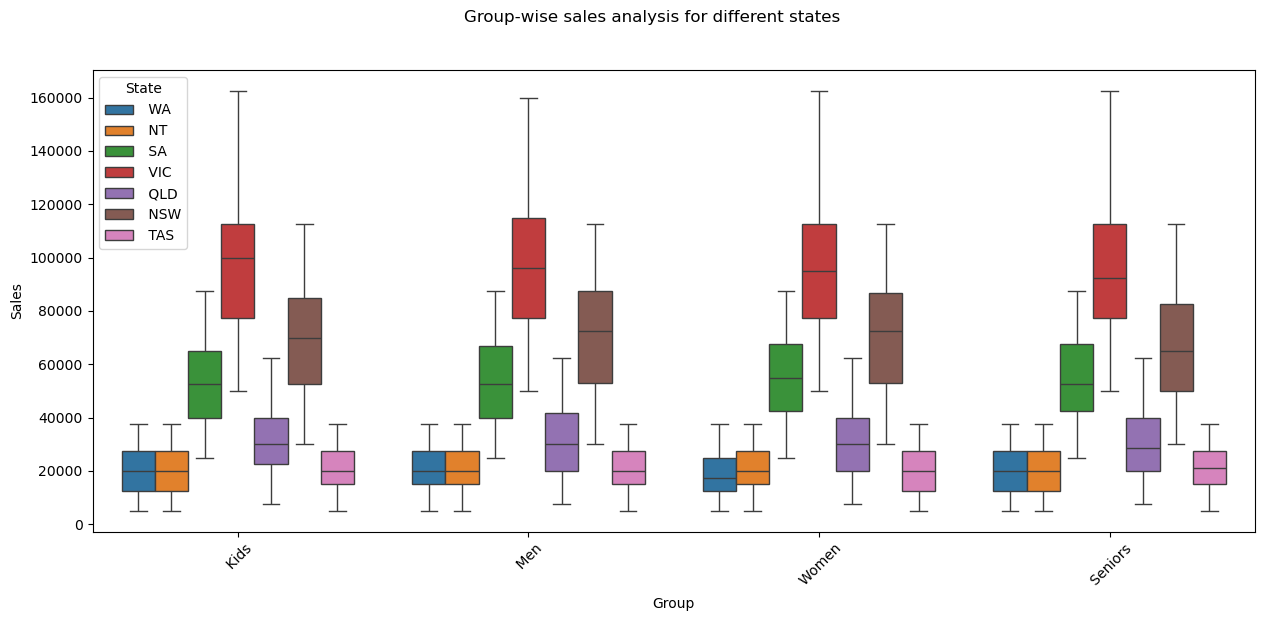

In [112]:

plt.figure(figsize=(15,6))

sns.boxplot(data=df, x='Group', y='Sales', hue='State')
plt.xticks(rotation=45)
plt.suptitle("Group-wise sales analysis for different states ")
plt.savefig(f'section_3A_Group-wise_sales_analysis_across_states.png')# Save plot as image
plt.show()
plt.close()

**Observations**
- Hightest sales are in Men group
- Lowest salesa are in Seniours group



## Section 3a:  Data visualization: Time-of-the-day analysis
Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
-  Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales.

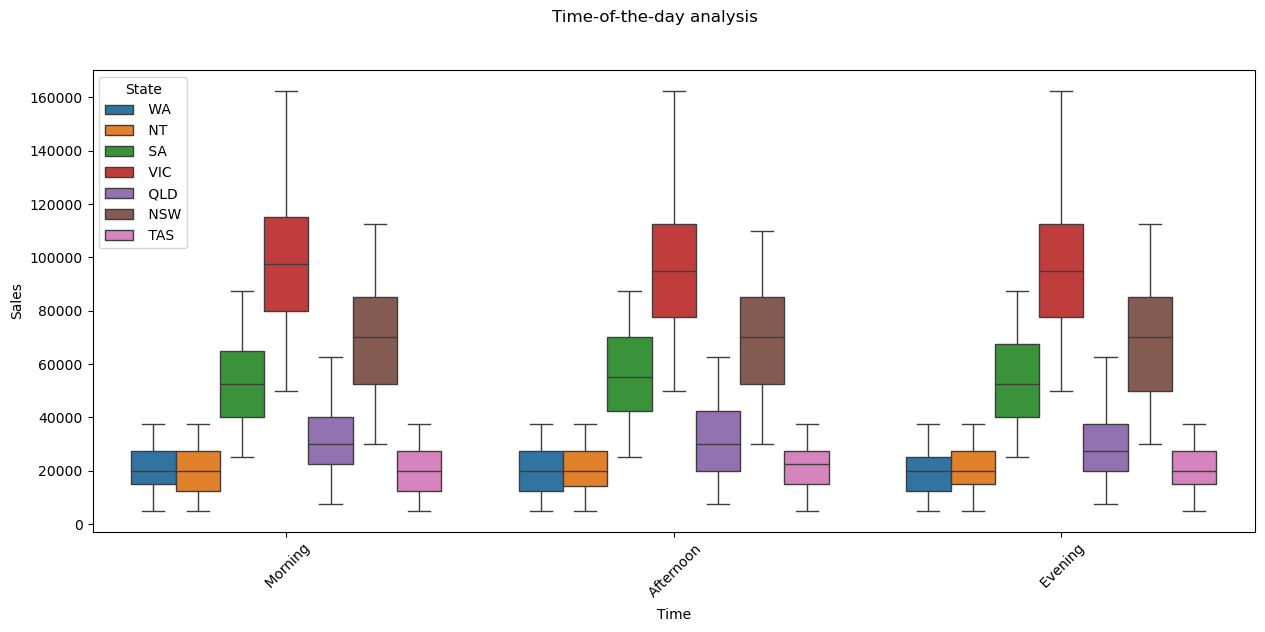

In [113]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df, x='Time', y='Sales', hue='State')
#sns.boxplot(data=df, x='Time', y='Sales')
plt.xticks(rotation=45)
plt.suptitle("Time-of-the-day analysis")
plt.savefig(f'section_3A_Time-of-the-day_analysis.png')# Save plot as image
plt.show()
plt.close()

**Observations**
- Sales are identical for any time of the day. 
- Sales patterns are consistent across different times of day
- No significant peak or off-peak periods identified
- Sales distribution remains stable throughout the day

## 3b 	Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
- The dashboards must contain daily, weekly, monthly, and quarterly charts.

## Section 3b: Data Visualization: Dashboard daily charts

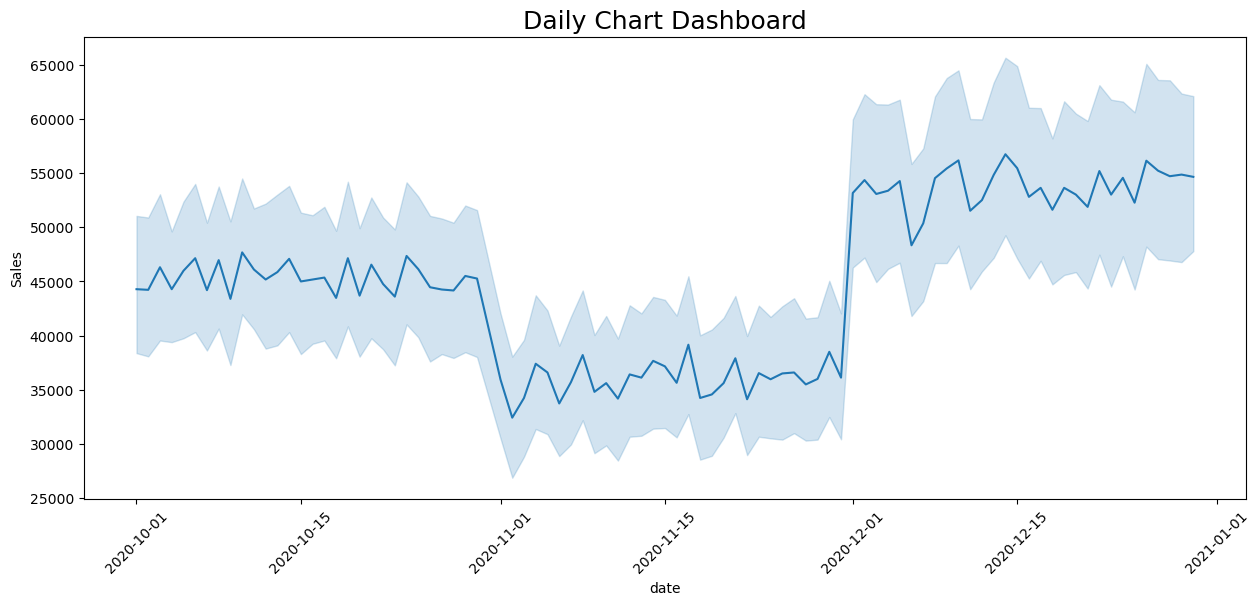

In [114]:
plt.figure(figsize=(15,6))
plt.title('Daily Chart Dashboard', fontsize=18)
#df['date'] = pd.to_datetime(df['Date'].astype(str) )
sns.lineplot(data=df, x='date', y='Sales')#,hue='Group')
plt.xticks(rotation=45)

plt.savefig(f'section_3B_Dashboard_Daily.png')# Save plot as image
plt.show()
plt.close()


**Observations**
- Highest Sale was on: 2020-12-14
- Lowest Sale was on: 2020-11-02
- Hightest sales in dates{} DatetimeIndex(['2020-12-14', '2020-12-10', '2020-12-26', '2020-12-15',
               '2020-12-09', '2020-12-27', '2020-12-22', '2020-12-29',
               '2020-12-13', '2020-12-28'],
- Lowest sales in dates{} DatetimeIndex(['2020-11-02', '2020-11-06', '2020-11-22', '2020-11-11',
               '2020-11-03', '2020-11-18', '2020-11-19', '2020-11-09',
               '2020-11-27', '2020-11-10'],

## Section 3b: Data Visualization: Dashboard weekly charts
- Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
- The dashboard must contain  weekly charts

        date     Sales
0 2020-10-04  15045000
1 2020-10-11  27002500
2 2020-10-18  26640000
3 2020-10-25  26815000
4 2020-11-01  21807500


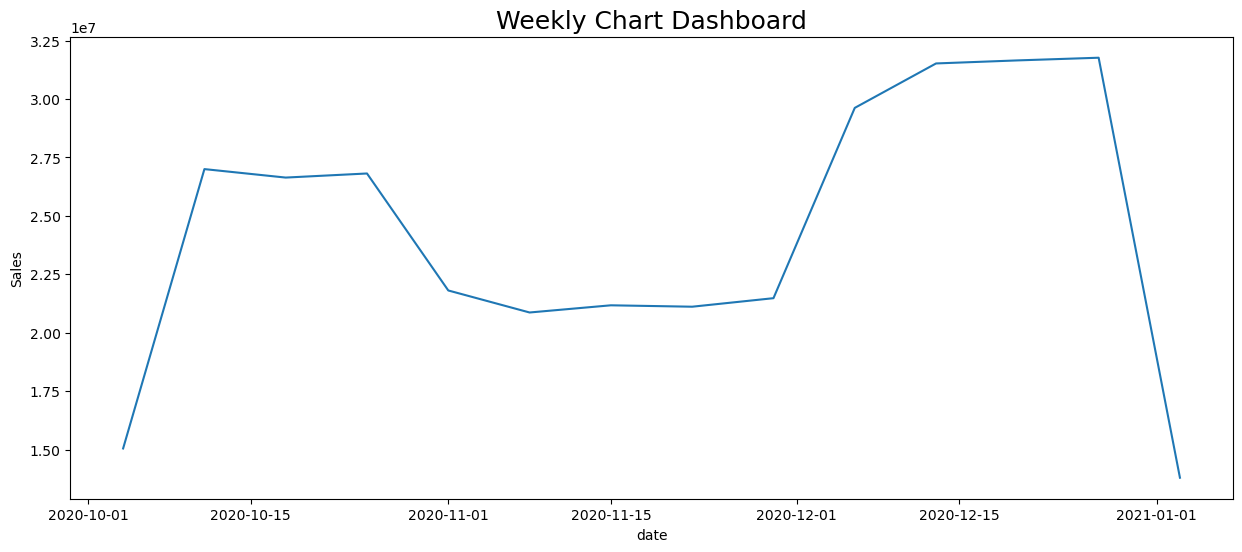

In [115]:
plt.figure(figsize=(15,6))
plt.title('Weekly Chart Dashboard', fontsize=18)
df_weekly = df.resample('W', on='date')['Sales'].sum().reset_index()
print(df_weekly.head())
sns.lineplot(data=df_weekly, x="date", y="Sales")
#plt.xticks(rotation=45)
plt.savefig(f'section_3B_Dashboard_Weekly.png')# Save plot as image
plt.show()
plt.close()


**Observations**
- Highest Sale was on the week: 2020-12-14
- Lowest Sale was on the week : 2020-11-02
- Hightest sales in dates{} DatetimeIndex(['2020-12-14', '2020-12-10', '2020-12-26', '2020-12-15',
               '2020-12-09', '2020-12-27', '2020-12-22', '2020-12-29',
               '2020-12-13', '2020-12-28'],
- Lowest sales in dates{} DatetimeIndex(['2020-11-02', '2020-11-06', '2020-11-22', '2020-11-11',
               '2020-11-03', '2020-11-18', '2020-11-19', '2020-11-09',
               '2020-11-27', '2020-11-10'],

**Observations**
- December month had highest sales compared to other months in the quarter

## Section 3b: Data Visualization: Dashboard mothly charts
- 	Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
- The dashboard must contain  monthly charts

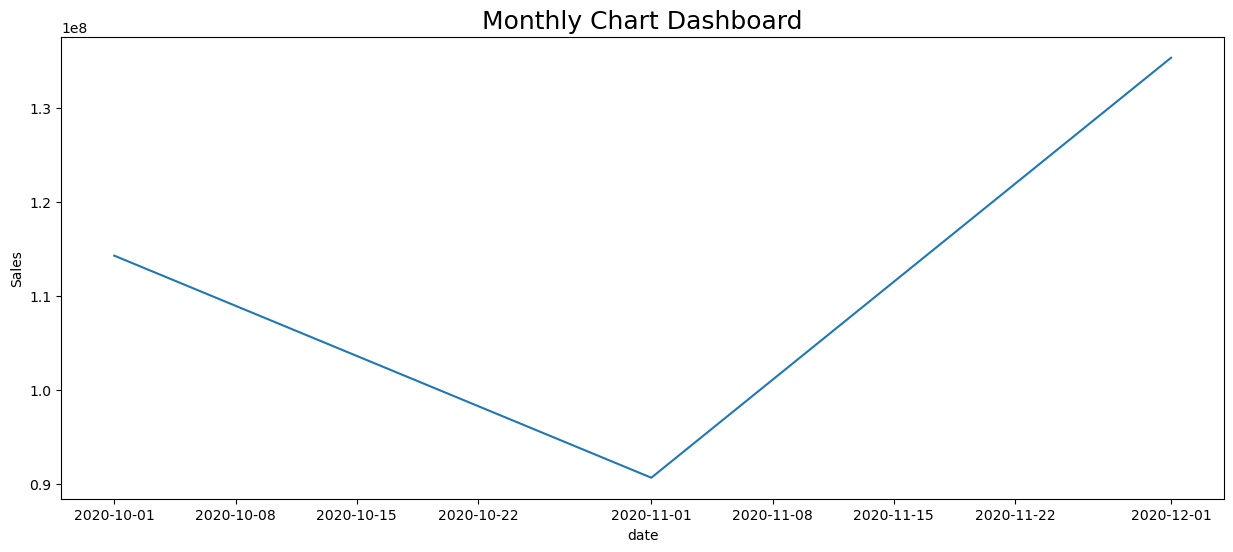

In [116]:
plt.figure(figsize=(15,6))
plt.title('Monthly Chart Dashboard', fontsize=18)
df_monthly = df.resample('MS', on='date')['Sales'].sum().reset_index()
sns.lineplot(data=df_monthly, x="date", y="Sales")

plt.savefig(f'section_3B_Dashboard_Monthly.png')# Save plot as image
plt.show()
plt.close()

**Observations**
- **December month had highest sales compared to other months in the quarter**
  - Highest Sale was in the month: 2020-12
  - Lowest Sale was in the month : 2020-10

## Section 3b: Data Visualization: Dashboard daily, weekly, mothly, quarterly charts
- 	Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
- The dashboard must contain  monthly charts

<Figure size 5500x5500 with 0 Axes>

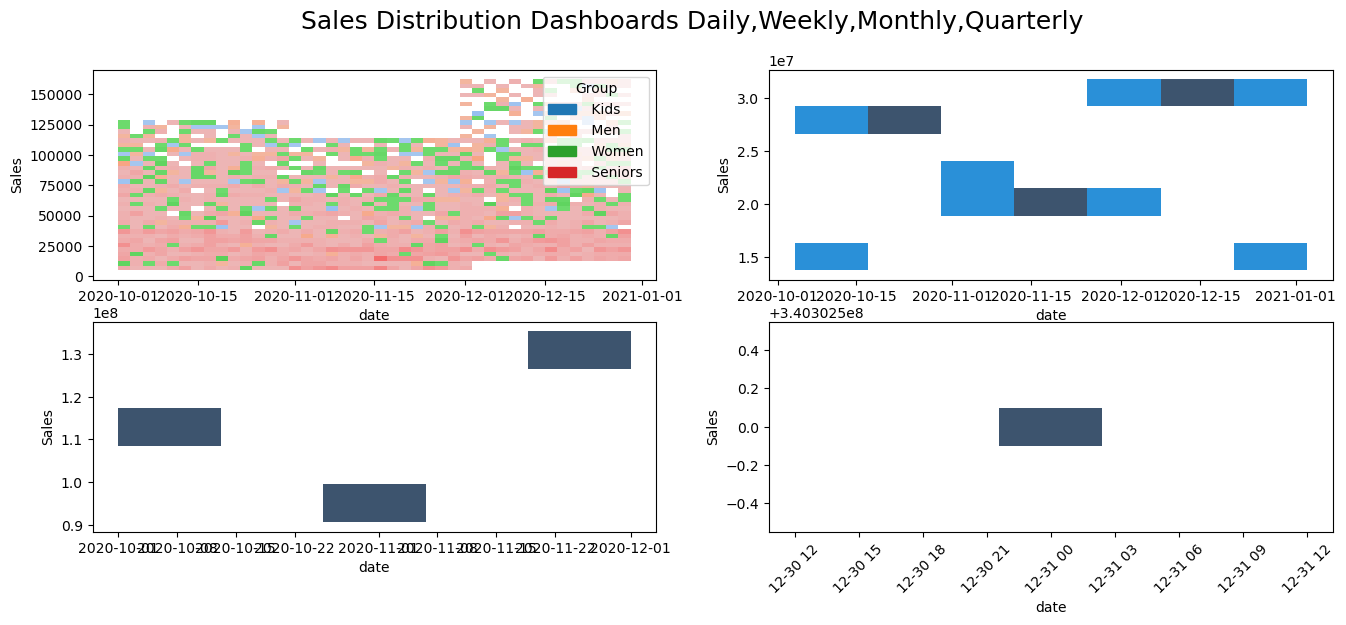

In [117]:
plt.figure(figsize=(55,55))

df_quarterly = df.resample('QE', on='date')['Sales'].sum().reset_index()
# build a grid with appropriate number of cells - 4 charts
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16,6))


sns.histplot(data=df, x='date', y='Sales', kde=True, bins=42, ax=axes[0,0], hue='Group',legend=True )
plt.xticks(rotation=45)
sns.histplot(data=df_weekly, x="date", y='Sales', kde=True, bins=7, ax=axes[0,1], legend=False )
plt.xticks(rotation=45)
sns.histplot(data=df_monthly, x="date", y='Sales', kde=True, bins=5, ax=axes[1,0],legend=False )
plt.xticks(rotation=45)
sns.histplot(data=df_quarterly, x="date", y='Sales', kde=True, bins=5, ax=axes[1,1])
plt.xticks(rotation=45)
# insert box plots
#fig.legend()
fig.suptitle('Sales Distribution Dashboards Daily,Weekly,Monthly,Quarterly', fontsize=18)
#fig.tight_layout()
plt.savefig(f'section_3B_Dashboard_All.png')# Save plot as image
plt.show()
plt.close()

**Observations**
- December month had highest sales compared to other months in the quarter

## Section 3b: Data Visualization: Dashboard daily, weekly, mothly, quarterly charts

<Figure size 2500x2600 with 0 Axes>

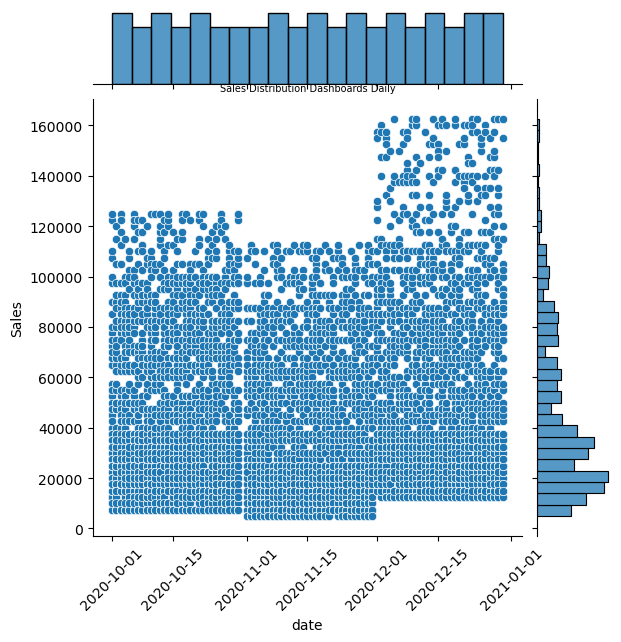

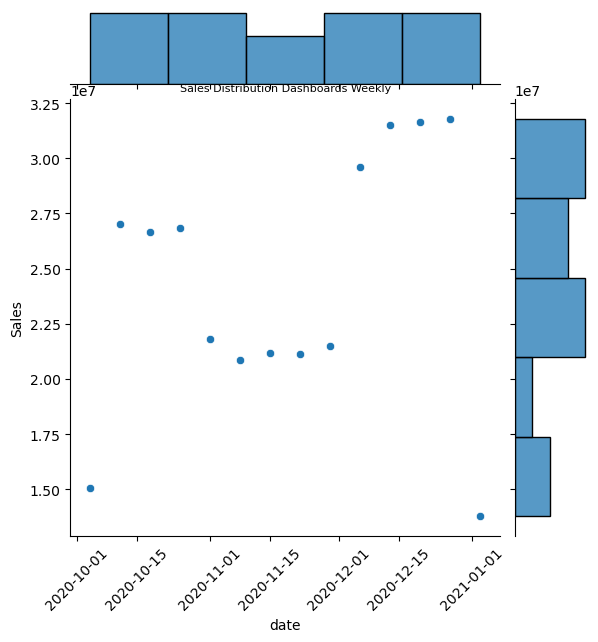

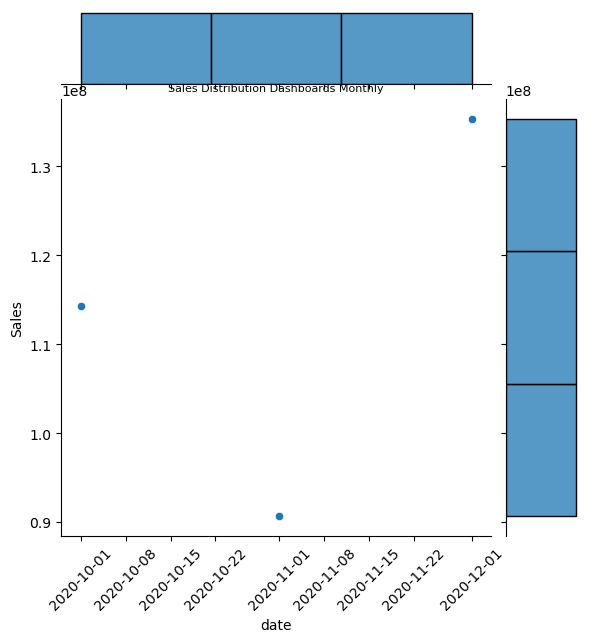

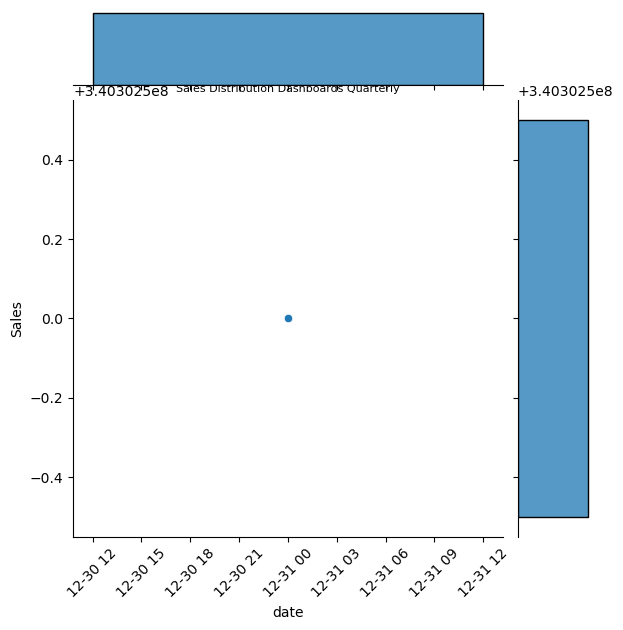

In [118]:
plt.figure(figsize=(25,26))

df_quarterly = df.resample('QE', on='date')['Sales'].sum().reset_index()
#,ax=plt.subplots(1,1,figsize=(10,5))
#sns.scatterplot(data=df, x='Date', y='Sales',  hue='Group',legend=True )
sns.jointplot(data=df, x='date', y='Sales',kind='scatter' )
plt.xticks(rotation=45)
plt.title('Sales Distribution Dashboards Daily', fontsize=7)
plt.show()
#sns.scatterplot(data=df_weekly, x="Date", y='Sales',hue='Group',legend=True  )
sns.jointplot(data=df_weekly, x="date", y='Sales',kind='scatter'  )
plt.xticks(rotation=45)
plt.title('Sales Distribution Dashboards Weekly', fontsize=8)
plt.show()
sns.jointplot(data=df_monthly, x="date", y='Sales',kind='scatter')
plt.xticks(rotation=45)
plt.title('Sales Distribution Dashboards Monthly', fontsize=8)
plt.show()

sns.jointplot(data=df_quarterly, x="date", y='Sales',kind='scatter')
plt.xticks(rotation=45)

plt.title('Sales Distribution Dashboards Quarterly', fontsize=8)

plt.savefig(f'section_3B_Dashboard_All_2.png')# Save plot as image
plt.show()
plt.close()

## Section 3b: Data Visualization: Dashboard quarterly charts
- 	Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
- The dashboard must contain quaterly charts

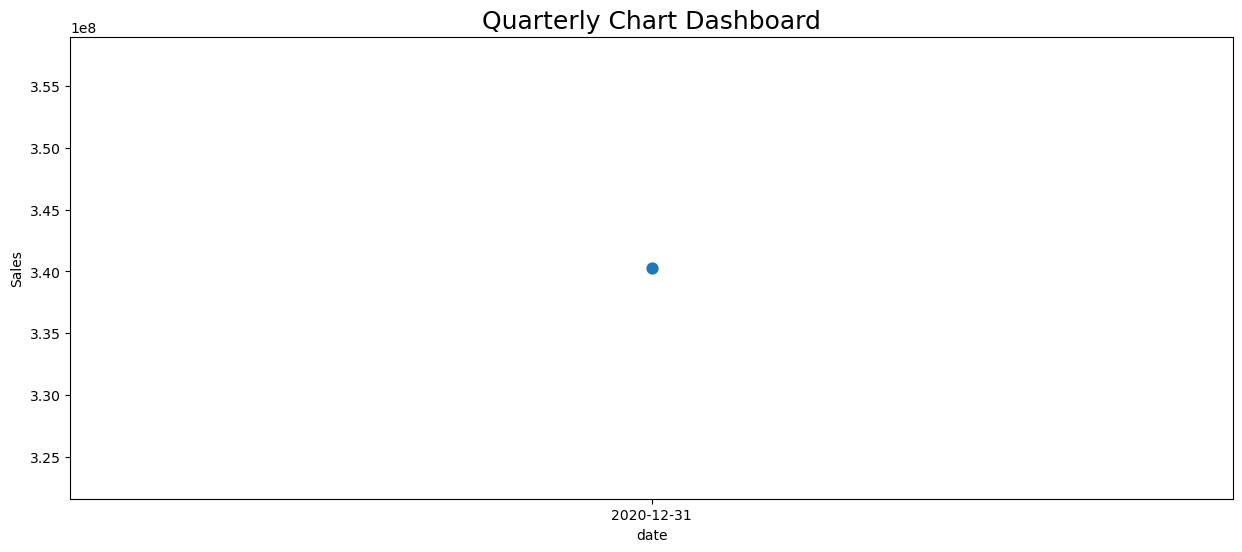

In [119]:
plt.figure(figsize=(15,6))
#df_quarterly = df.resample('QE', on='date').sum()
sns.pointplot(data=df_quarterly, x="date", y="Sales")
plt.title('Quarterly Chart Dashboard', fontsize=18)
plt.savefig(f'section_3B_Dashboard_Quaterly.png')# Save plot as image
plt.show()
plt.close()

**Observations**
Based on the analysis, the following recommendations are made:

1. **Targeted Marketing Programs**:
   - Develop specialized programs for Western Australia to boost sales
   - Implement hyper-personalization strategies for the Men's group
   - Create senior-friendly programs to increase senior sales

2. **Resource Allocation**:
   - Allocate more resources to high-performing states (VIC, NSW, SA)
   - Implement targeted sales training for lower-performing states : NT (Northern Territory) and WA (Western Australia)

3. **Data-Driven Decision Making**:
   - Use the analysis to guide investment decisions for the upcoming year
   - Implement continuous monitoring of sales patterns
